In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
print("Libraries Loaded")

Libraries Loaded


In [2]:
df = pd.read_csv("/Users/pushkal/Downloads/archive (3)/RELIANCE.csv") 
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5306, 15)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5306 entries, 0 to 5305
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5306 non-null   object 
 1   Symbol              5306 non-null   object 
 2   Series              5306 non-null   object 
 3   Prev Close          5306 non-null   float64
 4   Open                5306 non-null   float64
 5   High                5306 non-null   float64
 6   Low                 5306 non-null   float64
 7   Last                5306 non-null   float64
 8   Close               5306 non-null   float64
 9   VWAP                5306 non-null   float64
 10  Volume              5306 non-null   int64  
 11  Turnover            5306 non-null   float64
 12  Trades              2456 non-null   float64
 13  Deliverable Volume  4792 non-null   float64
 14  %Deliverble         4792 non-null   float64
dtypes: float64(11), int64(1), object(3)
memory usage: 621.9

Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     514
%Deliverble            514
dtype: int64

In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

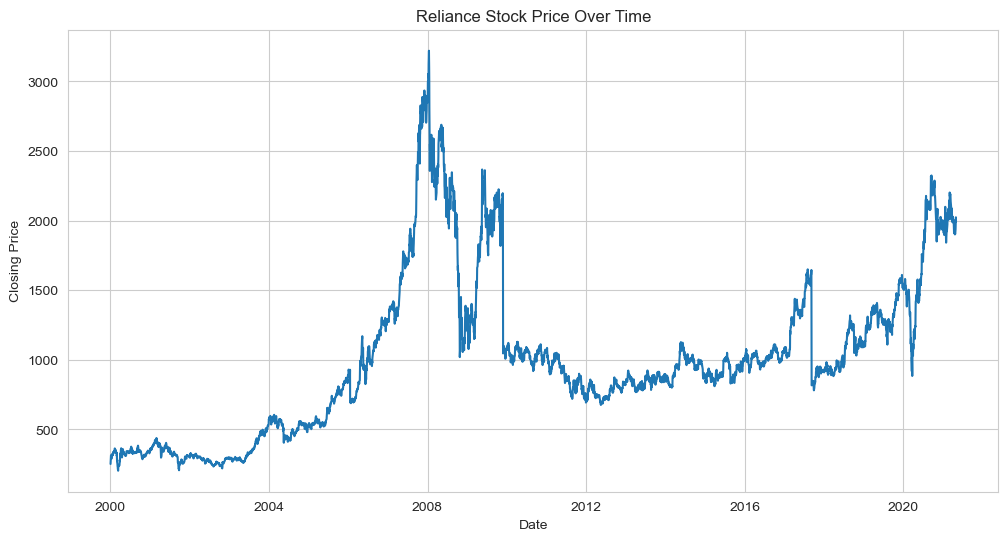

In [5]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df,
    x="Date",
    y="Close"
)
plt.title("Reliance Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

In [6]:
df["MA50"] = df["Close"].rolling(window=50).mean()
df["MA200"] = df["Close"].rolling(window=200).mean()

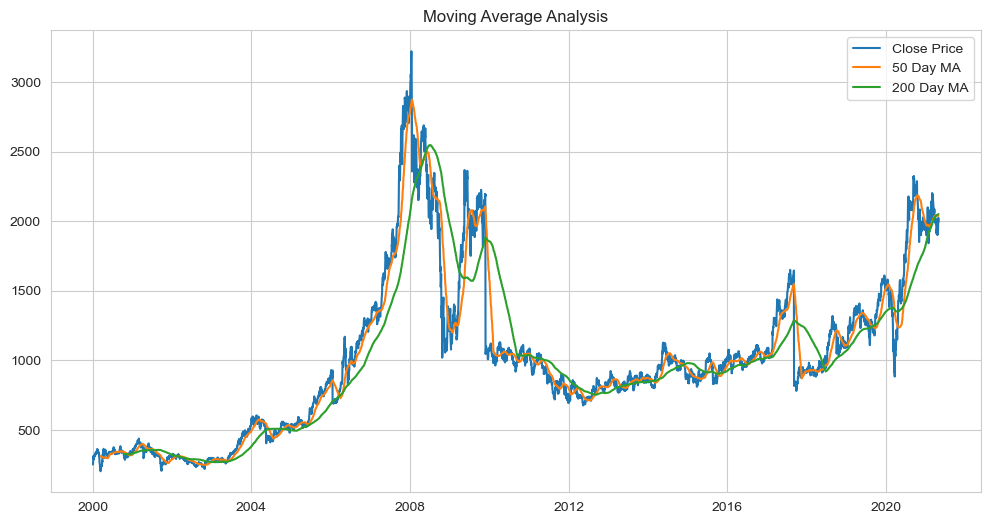

In [7]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"], label="Close Price")
plt.plot(df["Date"], df["MA50"], label="50 Day MA")
plt.plot(df["Date"], df["MA200"], label="200 Day MA")
plt.legend()
plt.title("Moving Average Analysis")
plt.show()

In [8]:
df["Daily Return"] = df["Close"].pct_change()

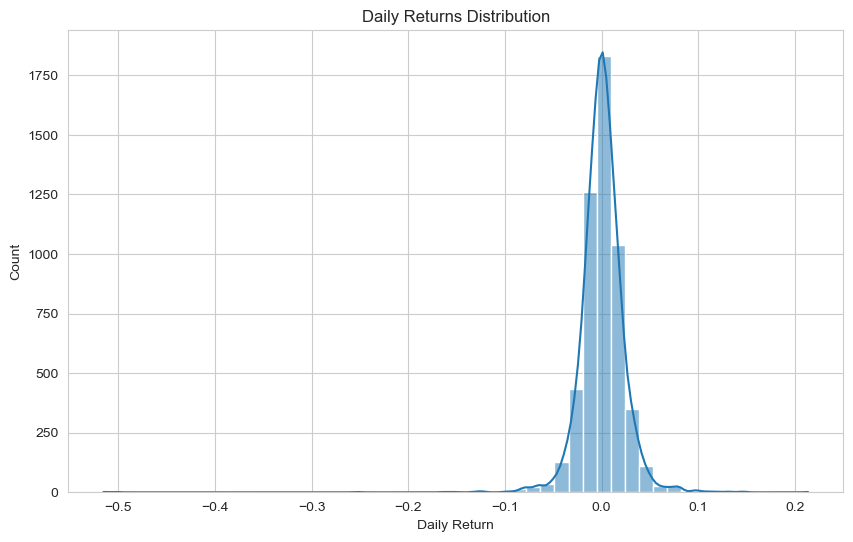

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(
    df["Daily Return"].dropna(),
    bins=50,
    kde=True
)
plt.title("Daily Returns Distribution")
plt.show()

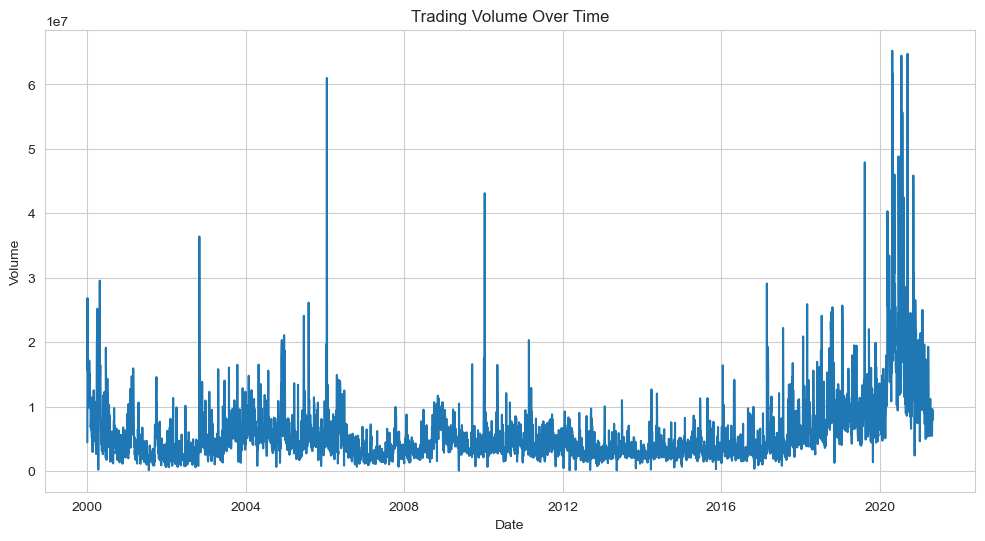

In [10]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=df,
    x="Date",
    y="Volume"
)
plt.title("Trading Volume Over Time")
plt.show()

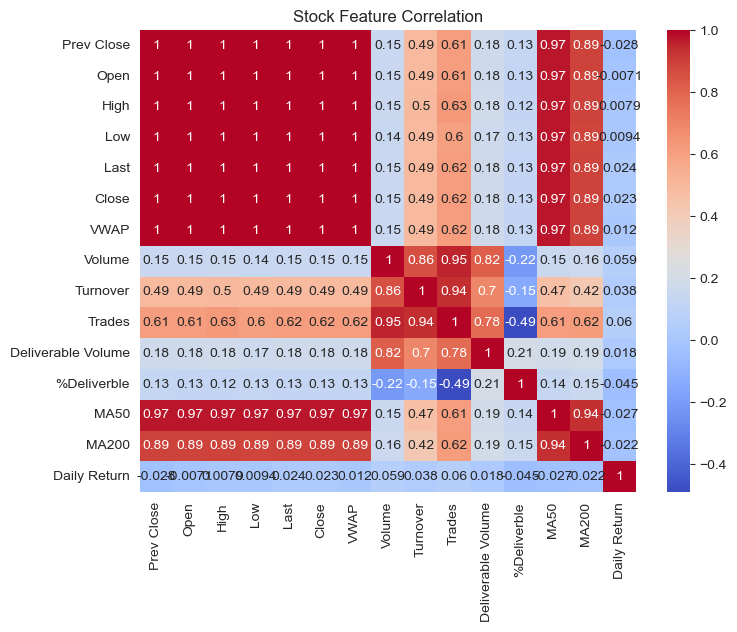

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Stock Feature Correlation")
plt.show()